
### 자동미분

- backward()로 미분 계산

In [3]:
import torch

torch.__version__

'2.12.0+cu126'

In [5]:
# 이전 미분계산
x = torch.tensor(2.0, requires_grad=True)

z = x ** 2
y = z * 3

y

tensor(12., grad_fn=<MulBackward0>)

- 최종결과 y에 .backward() 메서드 호출 : 파이토치가 계산 그래프를 역전파해서 각 텐서의 미분값을 자동 계산
- .grad 속성에 저장

In [ ]:
 # backward()
x = torch.tensor(2.0, requires_grad=True)

# 계산그래프 생성연산
z = x ** 2
y = z * 3

# y를 x에 대해 미분
# y = 3x^2
y.backward()

# x에 대한

### 경사하강법

- y = wx + b의 값을 구하는 모델 학습
- w : 가중치(weight)
- b : 절편()

In [7]:
# 학습할 가중치, 절편(편향) 정의
# w, b의 미분값을 계산하기때문 requires_grad = True
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# 입력데이터, 정답데이터
x = torch.tensor(2.0)
y_true = torch.tensor(5.0)  # 실제값. 모델이 정답이 틀려야 학습가능

# 순전파 : 모데릐 예측값 계산
y_pred = w * x + b
print(y_pred)

# 손실(loss) 계산
loss = (y_pred - y_true) **2

print(f'예측값 : {y_pred.item()}')
print(f'손실 : {loss.item()}')

# 역전파 : 손실에 대해 w와 b의 미부낪 계산
loss.backward()

# w와 b의 미분값 확인
# 기울기를 이용해서 w와 b를 업데이트하고 손실을 줄여나갈 수 있음
print(f'w의 미분값 : {w.grad}')
print(f'b의 미분값 : {b.grad}')


tensor(3., grad_fn=<AddBackward0>)
예측값 : 3.0
손실 : 4.0
w의 미분값 : -8.0
b의 미분값 : -4.0


#### 손실함수

오차를 숫자로 계산
- MSE(평균제곱 오차) : 예측값을 실제값으로 뺀 다음 제곱승
- MAE(평균절대오차) : 예측값과 실제값을 뺀 뒤 절대값의 평균

#### 학습률

- Learning rate : 얼마나 조금씩 수정할 지 결정하는 값

#### 선형회귀 모델 구현

In [ ]:
import torch

# 학습데이터
# 공부시간 / 시험점수
hours = torch.tensor([
    [1.],
    [2.],
    [3.],
    [4.],
    [5.]
])

scores = torch.tensor([
    [52.],
    [60.],
    [68.],
    [76.],
    [84.]
])

# 학습할 파라미터
w = torch.tensor([[1.0]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# 학습률
learning_rate = 0.1

# 1000번학습
for epoch in range(1000):
    # 1. 예측값 계산
    y_pred = hours @ w + b

    # 2. 손실함수(MSE)
    loss = torch.mean((y_pred - scores) ** 2)

    # 기존 기울기 초기화
    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()
    
    # 3. 역전파
    loss.backward()

    # 4. 경사하강법
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 100번 마다 출력
    if epoch % 100 == 0:
        print(f'epoch={epoch:4d} loss={loss.item():.4f} w={w.item():.4f} b={b.item():.4f}')

# 최종결과
print('\n최종학습결과')
print(f'기울기 w = {w.item():.4f}')
print(f'절편 b = {b.item():.4f}')

# 테스트 수행
# 테스트 수행
test_hours = torch.tensor([
    [6.],
    [7.],
    [8.]
])

with torch.no_grad():
    pred_scores = test_hours @ w + b

print('\n예측결과')
for h, s in zip(test_hours, pred_scores):
    print(f'{h.item():.0f}시간 공부 -> 예상점수 {s.item():.2f}')

- learning_rate를 계속 변경하면서 최적의 모델 찾기
- 0.1, 0.01, 0.001 반복테스트후
- 0.03이 가장 최적의 lr임을 확인
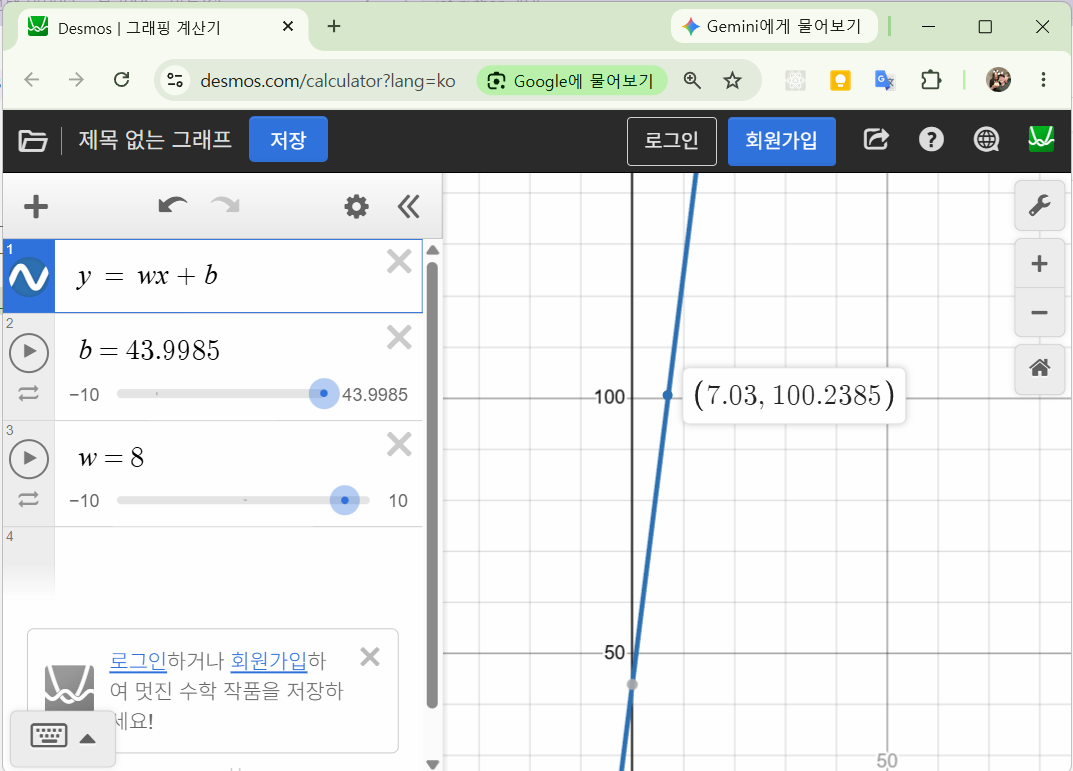

#### 파이토치 모델 사용하기

- 파이토치 모듈 사용 모델 생성
    1. 데이터준비
    2. 모델설계 - 파이토치 클래스 활용
    3. 손실함수 - 파이토치 손실함수 활용
    4. 옵티마이저 - 
    5. 모델 학습
    6. 모델 테스트

In [13]:
# 필요라이브러리 추가
import torch
import torch.nn as nn   # 신경망 모듈
import torch.optim as optim     # 손실함수 최적화 알고리즘 모듈

# y = 2x + 1

# 1. 데이터 준비

# 결과를 유사하게 만들 랜덤시드 설정
torch.manual_seed(42)

w_true = 2.0
b_true = 1.0

# 100개의 랜덤값 x를 생성
x = torch.randn(100) * 10

# 노이즈 생성 / 없어도 상관없음 / 일정한 값이 안나오도록 해줌
noise = torch.randn(100) * 2

# y값 생성 : y = 2x + 1 + noise
Y = w_true * x + b_true + noise

print(Y.size())

# 2. 모델설계 : 클래스로 생성. nn.Module 클래스 상송해서
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        # 학습 파라미터 w
        # 최초 랜덤값으로 시작
        self.w = nn.Parameter(torch.randn(1))

        # 학습 파라미터 b
        self.b = nn.Parameter(torch.randn(1))

    def forward(self, x):
        # 선형회귀 공식 y = wx + b
        y_pred = self.w * x + self.b
        return y_pred
    
# 모델 객체 생성
model = LinearRegression()

# 3. 손실함수
# MSE - 예측값과 실제값 차이를 제곱하고 평균
loss_fn = nn.MSELoss()

# 4. 옵티마이저
# SGD(확률적 경사 하강법)
# model.parameters() w, b
# lr(learning rate)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 5. 모델 학습
num_epochs = 1000

for epoch in range(num_epochs + 1):
    # 1) 순전파
    # 현재 w, b로 예측값 계산
    y_pred = model(x)

    # 2) 손실계산
    # 예측값, 실제값 차이 계산
    loss = loss_fn(y_pred, Y)

    # 3) 기존 기울기 초기화
    # PyTorch는 기울기를 누적함 매번 0으로 초기화
    optimizer.zero_grad()

    # 4) 역전파
    # loss를 기준으로 w, b의 미분값 계산
    loss.backward()

    # 5) 파라미터업데이트
    # 계산된 미분값을 이용해 w, b 조금씩 수정
    optimizer.step()

    # 100번마다 학습상태 출력
    if(epoch + 1)%100 == 0:
        print(
            f'epoch={epoch + 1:4d} loss = {loss.item():.4f} w = {model.w.item():.4f} b = {model.b.item():.4f}'
        )
# 6. 모델 평가
print('\n --- 최종 파라미터 ---')
print(f'학습된 w : {model.w.item():.4f}')
print(f'학습된 b : {model.b.item():.4f}')
print('-------------------------------------')
print(f'실제 w : {w_true}')
print(f'실제 b : {b_true}')

# 7. 예측 테스트
test_x = torch.tensor([5.0, 10.0, 15.0])

with torch.no_grad():
    test_y_pred = model(test_x)

print('\n=== 예측결과 ===')
for x,y in zip(test_x, test_y_pred):
    print(f'x = {x.item():.1f} -> 예측 y = {y.item():.4f}')

torch.Size([100])
epoch= 100 loss = 3.1519 w = 2.0017 b = 0.9008
epoch= 200 loss = 3.1220 w = 2.0025 b = 1.0486
epoch= 300 loss = 3.1215 w = 2.0024 b = 1.0683
epoch= 400 loss = 3.1214 w = 2.0024 b = 1.0709
epoch= 500 loss = 3.1214 w = 2.0024 b = 1.0713
epoch= 600 loss = 3.1214 w = 2.0024 b = 1.0713
epoch= 700 loss = 3.1214 w = 2.0024 b = 1.0713
epoch= 800 loss = 3.1214 w = 2.0024 b = 1.0713
epoch= 900 loss = 3.1214 w = 2.0024 b = 1.0713
epoch=1000 loss = 3.1214 w = 2.0024 b = 1.0713

 --- 최종 파라미터 ---
학습된 w : 2.0024
학습된 b : 1.0713
-------------------------------------
실제 w : 2.0
실제 b : 1.0

=== 예측결과 ===
x = 5.0 -> 예측 y = 11.0832
x = 10.0 -> 예측 y = 21.0950
x = 15.0 -> 예측 y = 31.1068


#### 다중퍼셉트론 예제

In [ ]:
# 1. 데이터 준비
import torch
import torch.nn as nn
import torch.optim as optim

# y = 2x + 1

# 결과를 유사하게 만들 랜덤시드 설정
torch.manual_seed(42)

w_true = 2.0
b_true = 1.0

# 100개의 랜덤값 x를 생성
x = torch.randn(100, 1) * 10    # (100, 1)

# Y값 생성 : y = 2x + 1 
Y = w_true * x + b_true

# 2. 다중퍼셉트론 모델 설계
class MLPRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # 입력 1 -> 은닉층 8개
            nn.Linear(in_features=1, out_features=8),
            # 활성화 함수
            nn.ReLU(),
            # 1st 은닉층 8개 -> 2nd 은닉층 8개
            nn.Linear(in_features=8, out_features=8),
            nn.ReLU(),
            # 2nd 은닉층 8개 -> 출력층 1개
            nn.Linear(in_features=8, out_features=1)
        )

    # ⚠️ [수정] 기존 'forware'에서 'forward'로 오타를 수정했습니다! (PyTorch 필수 예약어)
    def forward(self, x):
        return self.model(x)

# 3. 모델 생성
model = MLPRegression()

# 4. 손실함수
loss_fn = nn.MSELoss()

# 5. 옵티마이저
# SGD도 가능
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 6. 학습
num_epochs = 2000

for epoch in range(num_epochs):
    # 1) 순전파
    y_pred = model(x)

    # 2) 손실 계산
    loss = loss_fn(y_pred, Y)

    # 3) 기존 기울기 초기화
    optimizer.zero_grad()

    # 4) 역전파
    loss.backward()
    
    # 5) 가중치 업데이트 (기존 코드에서 빠져있던 필수 단계입니다!)
    optimizer.step()

    # 100번마다 출력
    if (epoch + 1) % 100 == 0:
        print(
            f'epoch = {epoch + 1:4d} | '
            f'loss = {loss.item():.6f}'
        )

# 7. 예측 테스트
test_x = torch.tensor([[5.0], [10.0], [15.0]])

with torch.no_grad():
    test_y_pred = model(test_x)

print('\n=== 예측 결과 ===')
for t_x, y in zip(test_x, test_y_pred):
    print(f'x = {t_x.item():.1f} -> 예측 y = {y.item():.4f}')

# 8. 실제 정답과 비교 (완성된 부분 )
print('\n=== 실제 정답 ===')
for t_x in test_x:
    true_y = w_true * t_x.item() + b_true
    print(f'x = {t_x.item():.1f} -> 실제 y = {true_y:.4f}')

epoch =  100 | loss = 1.122354
epoch =  200 | loss = 0.292612
epoch =  300 | loss = 0.060896
epoch =  400 | loss = 0.014023
epoch =  500 | loss = 0.007403
epoch =  600 | loss = 0.005716
epoch =  700 | loss = 0.004652
epoch =  800 | loss = 0.003840
epoch =  900 | loss = 0.003190
epoch = 1000 | loss = 0.002592
epoch = 1100 | loss = 0.002102
epoch = 1200 | loss = 0.001747
epoch = 1300 | loss = 0.001480
epoch = 1400 | loss = 0.001269
epoch = 1500 | loss = 0.001099
epoch = 1600 | loss = 0.000956
epoch = 1700 | loss = 0.000828
epoch = 1800 | loss = 0.000711
epoch = 1900 | loss = 0.000612
epoch = 2000 | loss = 0.000526

=== 예측 결과 ===
x = 5.0 -> 예측 y = 11.0078
x = 10.0 -> 예측 y = 21.0032
x = 15.0 -> 예측 y = 30.9986

=== 실제 정답 ===
x = 5.0 -> 실제 y = 11.0000
x = 10.0 -> 실제 y = 21.0000
x = 15.0 -> 실제 y = 31.0000
